# import moduls

In [50]:
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix , classification_report,ConfusionMatrixDisplay,precision_score,recall_score,roc_curve,auc,RocCurveDisplay
from matplotlib import pyplot as plt

# Create a binary dataset 90 % 10 %

In [51]:
np.random.seed(42)
class_1 = np.random.normal(loc=0,scale=0.5,size=900)
y_1 = np.zeros_like(class_1).astype(int)

class_2 = np.random.normal(loc=2,scale=0.5,size=100)
y_2 = np.ones_like(class_2).astype(int)

X , y = np.concatenate((class_1,class_2),axis=0) , np.concatenate((y_1,y_2),axis =0)

df = pd.DataFrame(data= {
    "X":X,
    "y":y
})
df = shuffle(df)
df.reset_index(drop=True,inplace=True)

display(df.head(10))

Xtrain, Xtest, ytrain, ytest = train_test_split(df.iloc[:,:-1],df.iloc[:,1],test_size=0.3,stratify=df.iloc[:,1],random_state=42)


,X,y
0,-0.564853,0
1,0.307083,0
2,-0.428579,0
3,0.037902,0
4,0.369233,0
5,0.410241,0
6,-0.109836,0
7,0.029104,0
8,-0.243563,0
9,-0.229680,0


# measure metrics

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       270
           1       1.00      0.83      0.91        30

    accuracy                           0.98       300
   macro avg       0.99      0.92      0.95       300
weighted avg       0.98      0.98      0.98       300



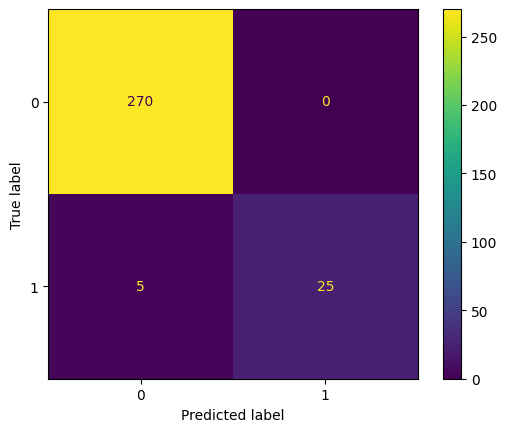

In [52]:
clf = LogisticRegression()
clf.fit(Xtrain,ytrain)
y_pred = clf.predict(Xtest)

clf_report = classification_report(y_true=ytest,y_pred=y_pred)
cm = confusion_matrix(y_true=ytest,y_pred=y_pred)
dsp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=clf.classes_)

print(clf_report)
dsp.plot()
plt.show()


# Test thresholds

,threshold 0.1,threshold 0.2,threshold 0.3,threshold 0.4,threshold 0.5,threshold 0.6,threshold 0.7,threshold 0.8
0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0


,precision,recall
0.1,0.731707,1.000000
0.2,0.878788,0.966667
0.3,0.966667,0.966667
0.4,0.962963,0.866667
0.5,1.000000,0.833333
0.6,1.000000,0.800000
0.7,1.000000,0.800000
0.8,1.000000,0.766667


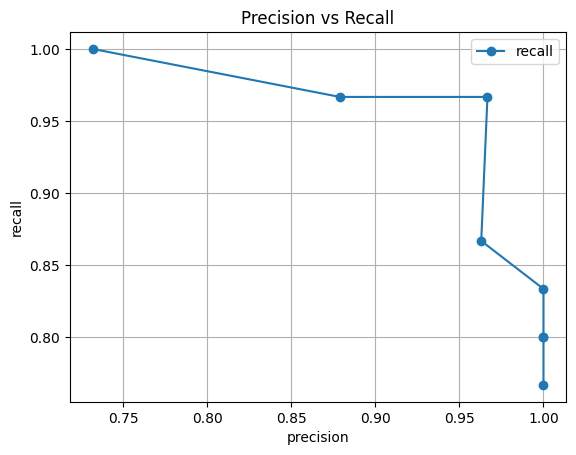

In [53]:
threshold = np.arange(0.1,0.9,0.1)
prob = clf.predict_proba(Xtest)[:,1]
df_threshold = pd.DataFrame()
df_scores = pd.DataFrame(index=threshold)
precision = list()
recall = list()
for i in threshold:
    predict = (prob > i).astype(int)
    df_threshold[f"threshold {i:.1f}"] = predict
    precision.append(precision_score(y_pred=predict,y_true=ytest))
    recall.append(recall_score(y_pred=predict,y_true=ytest))
df_scores['precision'] = precision
df_scores['recall'] = recall
display(df_threshold.head())
display(df_scores)
df_scores.plot(kind='line',x='precision',y='recall',marker = 'o')
plt.ylabel('recall')
plt.title('Precision vs Recall')
plt.grid()
plt.show()

# ROC | AUC

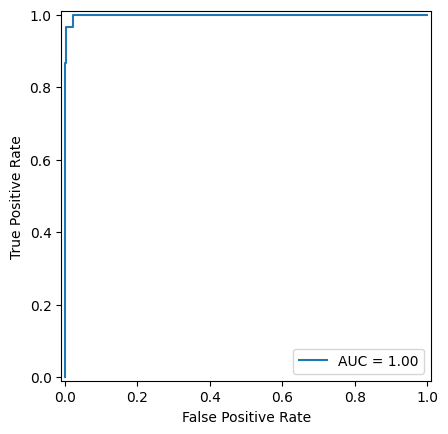

In [54]:
fpr, tpr, thresholds = roc_curve(y_score=prob,y_true=ytest)
roc_auc = auc(fpr,tpr)
dsp = RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc)
dsp.plot()
plt.show()

از آنجایی که آ یو سی از طریق محاسبه مساحت زیر نمودار مربوط به مدل ما به دست می آید یک مقدار است و برای هر ترش هولد یک مقدار جدا حساب نمی کند 

اگر مدلی تفکیک خوبی بین کلاس ها نداشته باشه باعث میشه fpr,tpr

کاهش پیدا کنه ولی ممکنه همچنان به علت پیش بینی داده های اکثریت معیار اکیورسی بالا باشه 